# Neural Network - Time Series - ECG

Author:
Majid Makhoul

## Imports

In [1]:
# Install dependencies into the CURRENT Jupyter kernel (lab3_tf)
import sys

!{sys.executable} -m pip install --upgrade pip
!{sys.executable} -m pip install numpy pandas matplotlib scikit-learn scipy wfdb

  Using cached pip-26.0.1-py3-none-any.whl.metadata (4.7 kB)
Using cached pip-26.0.1-py3-none-any.whl (1.8 MB)
  Attempting uninstall: pip
    Found existing installation: pip 24.3.1
    Uninstalling pip-24.3.1:
      Successfully uninstalled pip-24.3.1


In [2]:
import os
import ast
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, multilabel_confusion_matrix
)
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance
from sklearn.metrics import make_scorer

import wfdb
from scipy.signal import butter, filtfilt, find_peaks

## Setup
Paths + seed + choice of sampling rate (100 for now).

In [3]:
from pathlib import Path
import random
import numpy as np
import tensorflow as tf

# Paths, seed and choice of sampling rate (100 for now).
SUBMISSION_DIR = Path(".").resolve()
DATA_DIR = (SUBMISSION_DIR / "raw_data").resolve()

PTBXL_DB = DATA_DIR / "ptbxl_database.csv"
SCP_STMT = DATA_DIR / "scp_statements.csv"

USE_FS = 100  # can be changed to 500
SEED = 42

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    tf.keras.utils.set_random_seed(seed)

set_seed(SEED)

# TensorFlow device info (CPU/GPU)
gpus = tf.config.list_physical_devices("GPU")
device = "GPU" if len(gpus) > 0 else "CPU"

print("Device:", device)
print("DATA_DIR:", DATA_DIR)
print("USE_FS:", USE_FS)

2026-02-20 19:38:26.764347: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Device: CPU
DATA_DIR: /home/cmardini/PycharmProjects/ML_projects/Assignment 2/raw_data
USE_FS: 100


2026-02-20 19:38:28.391306: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## Load data

#### Load the metadata
We start with the CSV files, labels and paths.

In [4]:
df = pd.read_csv(PTBXL_DB)
scp = pd.read_csv(SCP_STMT)

print("ptbxl_database:", df.shape)
print("scp_statements:", scp.shape)
df.head(3)

ptbxl_database: (21799, 28)
scp_statements: (71, 13)


,ecg_id,patient_id,age,sex,height,weight,nurse,site,device,recording_date,...,validated_by_human,baseline_drift,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr
0,1,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,...,True,NaN,", I-V1,",NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr
1,2,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,...,True,NaN,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr
2,3,20372.0,37.0,1,NaN,69.0,2.0,0.0,CS-12 E,1984-11-15 12:49:10,...,True,NaN,NaN,NaN,NaN,NaN,NaN,5,records100/00000/00003_lr,records500/00000/00003_hr


In [5]:
scp.head(3)

,Unnamed: 0,description,diagnostic,form,rhythm,diagnostic_class,diagnostic_subclass,Statement Category,SCP-ECG Statement Description,AHA code,aECG REFID,CDISC Code,DICOM Code
0,NDT,non-diagnostic T abnormalities,1.0,1.0,NaN,STTC,STTC,other ST-T descriptive statements,non-diagnostic T abnormalities,NaN,NaN,NaN,NaN
1,NST_,non-specific ST changes,1.0,1.0,NaN,STTC,NST_,Basic roots for coding ST-T changes and abnorm...,non-specific ST changes,145.0,MDC_ECG_RHY_STHILOST,NaN,NaN
2,DIG,digitalis-effect,1.0,1.0,NaN,STTC,STTC,other ST-T descriptive statements,suggests digitalis-effect,205.0,NaN,NaN,NaN


### Lable space
we build the lable-set from `ptbxl_database.csv` and `scp_statements.csv`

In [6]:
def parse_scp_codes(x):
    # scp_codes in textform
    return ast.literal_eval(x) if isinstance(x, str) else {}

df["scp_dict"] = df["scp_codes"].apply(parse_scp_codes)
df["scp_list"] = df["scp_dict"].apply(lambda d: list(d.keys()))

print("Exempel scp_codes:", df["scp_list"].iloc[0][:10])

Exempel scp_codes: ['NORM', 'LVOLT', 'SR']


In [7]:
# Snabb koll: kolumnnamn kan skilja mellan versioner/exports
print("scp columns:", scp.columns.tolist())
scp.head(3)

scp columns: ['Unnamed: 0', 'description', 'diagnostic', 'form', 'rhythm', 'diagnostic_class', 'diagnostic_subclass', 'Statement Category', 'SCP-ECG Statement Description', 'AHA code', 'aECG REFID', 'CDISC Code', 'DICOM Code']


,Unnamed: 0,description,diagnostic,form,rhythm,diagnostic_class,diagnostic_subclass,Statement Category,SCP-ECG Statement Description,AHA code,aECG REFID,CDISC Code,DICOM Code
0,NDT,non-diagnostic T abnormalities,1.0,1.0,NaN,STTC,STTC,other ST-T descriptive statements,non-diagnostic T abnormalities,NaN,NaN,NaN,NaN
1,NST_,non-specific ST changes,1.0,1.0,NaN,STTC,NST_,Basic roots for coding ST-T changes and abnorm...,non-specific ST changes,145.0,MDC_ECG_RHY_STHILOST,NaN,NaN
2,DIG,digitalis-effect,1.0,1.0,NaN,STTC,STTC,other ST-T descriptive statements,suggests digitalis-effect,205.0,NaN,NaN,NaN


In [8]:
# I PTB-XL ligger själva labelkoden som index (kolumn 'Unnamed: 0')
# Vi gör den explicit → mycket tydligare och stabilare senare
if "Unnamed: 0" in scp.columns:
    scp = scp.rename(columns={"Unnamed: 0": "scp_code"})
    scp = scp.set_index("scp_code")

# Alla tillgängliga klasser från dictionary
dict_codes = set(scp.index)

print("Antal dictionary-koder:", len(dict_codes))
print("Exempel:", list(dict_codes)[:10])

Antal dictionary-koder: 71
Exempel: ['IPMI', 'TRIGU', 'PSVT', 'VCLVH', 'ALMI', 'INVT', 'SR', 'IRBBB', '3AVB', 'ISCAL']


In [9]:
all_codes = sorted({c for row in df["scp_list"] for c in row})

label_codes = [c for c in all_codes if c in dict_codes]
print("Antal labels (inkl extra):", len(label_codes))
print("Exempel labels:", label_codes[:15])

Antal labels (inkl extra): 71
Exempel labels: ['1AVB', '2AVB', '3AVB', 'ABQRS', 'AFIB', 'AFLT', 'ALMI', 'AMI', 'ANEUR', 'ASMI', 'BIGU', 'CLBBB', 'CRBBB', 'DIG', 'EL']


### Sanity chech (paths and reading a record)
Before trainging, we can confirm the the file path in `ptbxl_database.csv´ match the disk

In [10]:
# Pick a small set of records and verify their existens
# This helps catch path mistakes early and avoids debugging later
for i in [0, 1, 2]:
    base_lr = DATA_DIR / df.iloc[i]["filename_lr"]
    hea = Path(str(base_lr) + ".hea")
    dat = Path(str(base_lr) + ".dat")
    print(f"Record {i}:")
    print("  base:", base_lr)
    print("  hea exists:", hea.exists(), "| dat exists:", dat.exists())

Record 0:
  base: /home/cmardini/PycharmProjects/ML_projects/Assignment 2/raw_data/records100/00000/00001_lr
  hea exists: True | dat exists: True
Record 1:
  base: /home/cmardini/PycharmProjects/ML_projects/Assignment 2/raw_data/records100/00000/00002_lr
  hea exists: True | dat exists: True
Record 2:
  base: /home/cmardini/PycharmProjects/ML_projects/Assignment 2/raw_data/records100/00000/00003_lr
  hea exists: True | dat exists: True


In [11]:
# Read a single ECG to confirm wfdb works and shapes look right
row0 = df.iloc[0]
sig, meta = wfdb.rdsamp(str(DATA_DIR / row0["filename_lr"]))
print("Signal shape (T, leads):", sig.shape)
print("Sampling rate:", meta.get("fs"))

Signal shape (T, leads): (1000, 12)
Sampling rate: 100


 Multi-label classification is a definition problem. Each ECG can have multiple labels

In [12]:
print("Number of labels (dictionary ∩ dataset):", len(label_codes))
print("Example labels:", label_codes[:15])

Number of labels (dictionary ∩ dataset): 71
Example labels: ['1AVB', '2AVB', '3AVB', 'ABQRS', 'AFIB', 'AFLT', 'ALMI', 'AMI', 'ANEUR', 'ASMI', 'BIGU', 'CLBBB', 'CRBBB', 'DIG', 'EL']


Train, validation, test split

We use the PTB-XL split based on `start_fold´, train (1-8), Val (9), Test (10).

In [13]:
# Using strat_fold is standard for PTB-XL and keeps evaluation comparable
train_idx = df.index[df["strat_fold"].between(1, 8)].to_numpy()
val_idx   = df.index[df["strat_fold"] == 9].to_numpy()
test_idx  = df.index[df["strat_fold"] == 10].to_numpy()

print("Train:", len(train_idx))
print("Val:  ", len(val_idx))
print("Test: ", len(test_idx))

Train: 17418
Val:   2183
Test:  2198


In [14]:
# Label-frequency check (top-10) helps to see class imbalance
def multihot(codes):
    y = np.zeros(len(label_codes), dtype=np.float32)
    for c in codes:
        if c in label2idx:
            y[label2idx[c]] = 1.0
    return y

label2idx = {c:i for i,c in enumerate(label_codes)}

Y_train = np.vstack([multihot(df.loc[i, "scp_list"]) for i in train_idx])
freq = Y_train.sum(axis=0)

top = np.argsort(-freq)[:10]
print("Top-10 label frequency in train:")
for j in top:
    print(f"  {label_codes[j]:<6}  count={int(freq[j])}")

Top-10 label frequency in train:
  SR      count=13404
  NORM    count=7596
  ABQRS   count=2683
  IMI     count=2143
  ASMI    count=1887
  LVH     count=1708
  NDT     count=1461
  LAFB    count=1298
  AFIB    count=1211
  ISC_    count=1019


### Build datasets (numpy) for Keras
Keras works well with numpy arrays and we load ECG signalsns as ´(T, 12)´ and targets as 71

In [15]:
# Settings for loading signals
USE_FS = 100          # 100Hz is enough for a first model and much lighter than 500Hz
SECONDS = 10          # PTB-XL records are 10 seconds
T_MAX = USE_FS * SECONDS

def load_signal_by_index(i, fs=100):
    # Uses filename_lr or filename_hr depending on fs
    row = df.loc[i]
    rel = row["filename_lr"] if fs == 100 else row["filename_hr"]
    sig, _ = wfdb.rdsamp(str(DATA_DIR / rel))  # (T,12)
    return sig

def fix_length(sig, T=T_MAX):
    # pad/trim to exactly T samples
    if sig.shape[0] > T:
        return sig[:T]
    if sig.shape[0] < T:
        pad = np.zeros((T - sig.shape[0], sig.shape[1]), dtype=sig.dtype)
        return np.vstack([sig, pad])
    return sig

def standardize_per_record(sig):
    # Standardize per lead for each record
    mu = sig.mean(axis=0, keepdims=True)
    sd = sig.std(axis=0, keepdims=True) + 1e-6
    return (sig - mu) / sd

In [16]:
# Subset sizes
N_TRAIN = 8000
N_VAL   = 2000
N_TEST  = 2000

train_sub = train_idx[:N_TRAIN]
val_sub   = val_idx[:N_VAL]
test_sub  = test_idx[:N_TEST]

print("Subset sizes:", len(train_sub), len(val_sub), len(test_sub))

Subset sizes: 8000 2000 2000


In [17]:
# Load data into numpy arrays
def build_xy(indices):
    X = np.zeros((len(indices), T_MAX, 12), dtype=np.float32)
    Y = np.zeros((len(indices), len(label_codes)), dtype=np.float32)

    for k, i in enumerate(indices):
        sig = load_signal_by_index(int(i), fs=USE_FS)
        sig = fix_length(sig, T=T_MAX)
        sig = standardize_per_record(sig)
        X[k] = sig.astype(np.float32)

        Y[k] = multihot(df.loc[int(i), "scp_list"])

        # Small progress print, helps debuging
        if (k + 1) % 1000 == 0:
            print(f"Loaded {k+1}/{len(indices)}")

    return X, Y

X_train, y_train = build_xy(train_sub)
X_val,   y_val   = build_xy(val_sub)
X_test,  y_test  = build_xy(test_sub)

print("X_train:", X_train.shape, "y_train:", y_train.shape)

Loaded 1000/8000
Loaded 2000/8000
Loaded 3000/8000
Loaded 4000/8000
Loaded 5000/8000
Loaded 6000/8000
Loaded 7000/8000
Loaded 8000/8000
Loaded 1000/2000
Loaded 2000/2000
Loaded 1000/2000
Loaded 2000/2000
X_train: (8000, 1000, 12) y_train: (8000, 71)


## Task 1: Neural network design (model implementation)

Designing a neural network to classify 12-lead ECG time series from the PTB-XL. Because of ECG can have multiple SCP codes, the network outputs a vector of probabilities for each clas.

In [18]:
# TensorFlow/Keras for the model (runs in the lab3_tf environment)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow:", tf.__version__)
print("Num GPUs Available:", len(tf.config.list_physical_devices("GPU")))

TensorFlow: 2.20.0
Num GPUs Available: 0


In [19]:
# Model input configuration
# PTB-XL: 10 seconds at 100 Hz → 1000 samples, 12 leads
T_MAX = 1000
N_LEADS = 12
N_LABELS = 71   # from PTB-XL dataset specification

INPUT_SHAPE = (T_MAX, N_LEADS)

print("Input shape:", INPUT_SHAPE)
print("Number of labels:", N_LABELS)

Input shape: (1000, 12)
Number of labels: 71


In [20]:
# Reproducibility: makes results easier to compare between runs
SEED = 42
tf.keras.utils.set_random_seed(SEED)

In [21]:
# Input shape matches our numpy arrays: (T_MAX, 12) or (1000, 12)
INPUT_SHAPE = (T_MAX, 12)
N_LABELS = 71

def build_cnn_model(input_shape=INPUT_SHAPE, n_labels=N_LABELS):
    inp = keras.Input(shape=input_shape)

    # Feature extractor
    x = layers.Conv1D(32, kernel_size=7, padding="same", activation="relu")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPool1D(pool_size=2)(x)

    x = layers.Conv1D(64, kernel_size=5, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPool1D(pool_size=2)(x)

    x = layers.Conv1D(128, kernel_size=3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)

    # Global pooling
    x = layers.GlobalAveragePooling1D()(x)

    # Classification head
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.3)(x)

    # Multi-label output
    out = layers.Dense(n_labels, activation="sigmoid")(x)

    return keras.Model(inp, out)

model = build_cnn_model()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 1000, 12)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 1000, 32)       │         2,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1000, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 500, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 500, 64)        │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 500, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 250, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 250, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 250, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 71)             │         9,159 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 64,295 (251.15 KB)

 Trainable params: 63,847 (249.40 KB)

 Non-trainable params: 448 (1.75 KB)

## Task 2: model veriffication and preparation

Verifying the model, inout data and labels are consistent before training. Inspect label imbalance and confirm the network produces valid probability outputs. 

In [22]:
# Sanity check, saves time than to notice missmatch under training.
print("X_train:", X_train.shape, X_train.dtype)
print("y_train:", y_train.shape, y_train.dtype)

print("Expected input:", (None, *INPUT_SHAPE))
print("Expected labels:", N_LABELS)

assert X_train.shape[1:] == INPUT_SHAPE, "X_train shape matchar inte INPUT_SHAPE"
assert y_train.shape[1] == N_LABELS, "y_train matchar inte N_LABELS"

X_train: (8000, 1000, 12) float32
y_train: (8000, 71) float32
Expected input: (None, 1000, 12)
Expected labels: 71


In [23]:
# Compile the model
# Multi-label -> sigmoid output + binary cross-entropy
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.BinaryCrossentropy(),
    metrics=[
        keras.metrics.AUC(curve="ROC", multi_label=True, name="auc_roc"),
        keras.metrics.AUC(curve="PR",  multi_label=True, name="auc_pr"),
    ],
)
print("Model compiled")

Model compiled


In [24]:
# Fast forward pass: make sure the model can produce outputs without errors
# Output between [0,1]
batch_x = X_train[:8]
pred = model.predict(batch_x, verbose=0)

print("Pred shape:", pred.shape)
print("Pred min/max:", float(pred.min()), float(pred.max()))

assert pred.shape == (8, N_LABELS), "Prediction shape är inte (batch, N_LABELS)"
assert pred.min() >= -1e-6 and pred.max() <= 1 + 1e-6, "Sigmoid output ska ligga nära [0, 1]"

Pred shape: (8, 71)
Pred min/max: 0.42504310607910156 0.5745008587837219


In [25]:
# class imbalance is common in PTB-XL (Some labels are common)
freq = y_train.sum(axis=0)  # positive number per label
top_idx = freq.argsort()[-10:][::-1]

print("Top-10 labels (train subset):")
for j in top_idx:
    # If you have label_codes-lista: label_codes[j] is label-namnet
    label_name = label_codes[j] if "label_codes" in globals() else f"label_{j}"
    print(f"  {label_name:<6}  count={int(freq[j])}")

Top-10 labels (train subset):
  SR      count=6266
  NORM    count=3833
  IMI     count=847
  ABQRS   count=837
  ASMI    count=767
  LVH     count=752
  NDT     count=688
  LAFB    count=598
  AFIB    count=489
  STD_    count=474


In task 2 we have verified that input/output dimensions matches the model. The model is compiled with loss/metrics adapted to multi-label and a forward pass works and gives probability within [0,1].

### Minimal data cleaning and normalization

To keep the ECG waveforms close to raw signals while avoiding training instabilities, a light preprocessing step is applied,
- Replace NaN/Inf values with 0.
- Clip  amplitudes per lead using percentiles (winsorization) to reduce rare spikes.
- Robust normalization per recording and lead (median/IQR) to make scale comparable without leaking information across splits.

In [26]:
import numpy as np

def fit_clip_limits_from_train(X_train, clip_low=0.5, clip_high=99.5):
    X_train = np.asarray(X_train, dtype=np.float32)
    X_train = np.nan_to_num(X_train, nan=0.0, posinf=0.0, neginf=0.0)

    lo = np.percentile(X_train, clip_low, axis=(0, 1), keepdims=True) # (1,1,C)
    hi = np.percentile(X_train, clip_high, axis=(0, 1), keepdims=True)# (1,1,C)
    return lo.astype(np.float32), hi.astype(np.float32)

def clean_ecg_batch(X, lo, hi, eps=1e-8):
    X = np.asarray(X, dtype=np.float32)

    # 1) NaN/Inf to 0
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

    # 2) Clip with train-fitted limits
    X = np.clip(X, lo, hi)

    # 3) Robust normalization per recording and lead
    med = np.median(X, axis=1, keepdims=True) # (N,1,C)
    q75 = np.percentile(X, 75, axis=1, keepdims=True)
    q25 = np.percentile(X, 25, axis=1, keepdims=True)
    iqr = (q75 - q25)

    X = (X - med) / (iqr + eps)
    return X.astype(np.float32)

In [27]:
# Apply cleaning
print("Before cleaning:")
print("X_train:", X_train.shape, X_train.dtype)
print("X_val:  ", X_val.shape, X_val.dtype)
print("X_test: ", X_test.shape, X_test.dtype)

lo, hi = fit_clip_limits_from_train(X_train, clip_low=0.5, clip_high=99.5)

X_train = clean_ecg_batch(X_train, lo, hi)
X_val   = clean_ecg_batch(X_val, lo, hi)
X_test  = clean_ecg_batch(X_test, lo, hi)

print("\nAfter cleaning:")
print("X_train:", X_train.shape, X_train.dtype, "min/max:", float(X_train.min()), float(X_train.max()))
print("X_val:  ", X_val.shape,   X_val.dtype,   "min/max:", float(X_val.min()),   float(X_val.max()))
print("X_test: ", X_test.shape,  X_test.dtype,  "min/max:", float(X_test.min()),  float(X_test.max()))

# Sanity checks
assert np.isfinite(X_train).all() and np.isfinite(X_val).all() and np.isfinite(X_test).all()

Before cleaning:
X_train: (8000, 1000, 12) float32
X_val:   (2000, 1000, 12) float32
X_test:  (2000, 1000, 12) float32

After cleaning:
X_train: (8000, 1000, 12) float32 min/max: -52.075531005859375 91.93710327148438
X_val:   (2000, 1000, 12) float32 min/max: -52.151981353759766 45.400421142578125
X_test:  (2000, 1000, 12) float32 min/max: -37.80433654785156 48.20808792114258


### Task 3: Model Training

Train the neural network on the training split, monitor validation performance and evaluate the test split. The usage of sigmoid outputs and binary cross-entropy because of the multi-labled problem. 

In [28]:
from pathlib import Path

# All saved models must go here
MODELS_DIR = Path("models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Temp checkpoint path
tmp_model_path = MODELS_DIR / "best_model.keras"

In [29]:
import os
from datetime import datetime

# Ensure models folder exists
os.makedirs("models", exist_ok=True)

# Naming standard: type_score_datetime  (example: svm_81_24010511157)
timestamp = datetime.now().strftime("%y%m%d%H%M%S")

# We don't know the score yet at compile-time therefor, we store with a temporary name first
tmp_model_name = f"cnn_tmp_{timestamp}.keras"
tmp_model_path = os.path.join("models", tmp_model_name)

In [30]:
import tensorflow as tf
from tensorflow import keras

# Loss for multi-label classification
loss_fn = keras.losses.BinaryCrossentropy()

# Standard metrics that work well for multi-label
metrics = [
    keras.metrics.BinaryAccuracy(name="bin_acc", threshold=0.5),
    keras.metrics.AUC(name="auc", curve="ROC", multi_label=True),
    keras.metrics.AUC(name="pr_auc", curve="PR", multi_label=True),
]

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=loss_fn,
    metrics=metrics
)

# Callbacks: early stopping + save best model
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    keras.callbacks.ModelCheckpoint(
    filepath=str(tmp_model_path),
    monitor="val_loss",
    save_best_only=True
    ),
]

print("Model compiled.")

Model compiled.


In [31]:
BATCH_SIZE = 32
EPOCHS = 30

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30


2026-02-20 19:39:42.141213: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 384000000 exceeds 10% of free system memory.


249/250 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - auc: 0.5088 - bin_acc: 0.8936 - loss: 0.2984 - pr_auc: 0.0467

2026-02-20 19:39:50.487102: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 96000000 exceeds 10% of free system memory.


250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - auc: 0.5891 - bin_acc: 0.9508 - loss: 0.1688 - pr_auc: 0.0530 - val_auc: 0.6646 - val_bin_acc: 0.9720 - val_loss: 0.0960 - val_pr_auc: 0.0900
Epoch 2/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - auc: 0.6923 - bin_acc: 0.9730 - loss: 0.0925 - pr_auc: 0.0931 - val_auc: 0.7248 - val_bin_acc: 0.9723 - val_loss: 0.0910 - val_pr_auc: 0.1145
Epoch 3/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - auc: 0.7291 - bin_acc: 0.9739 - loss: 0.0859 - pr_auc: 0.1234 - val_auc: 0.7242 - val_bin_acc: 0.9729 - val_loss: 0.0883 - val_pr_auc: 0.1391
Epoch 4/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - auc: 0.7451 - bin_acc: 0.9746 - loss: 0.0819 - pr_auc: 0.1417 - val_auc: 0.7551 - val_bin_acc: 0.9735 - val_loss: 0.0840 - val_pr_auc: 0.1547
Epoch 5/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - auc: 0.7631 - bin_acc: 0.9753 - loss: 0.0792 - pr_auc: 0.1567 - val_auc: 0.7646 - val_bin_acc: 0.9741 - val_loss: 0.0823 - val_pr_auc: 0.1655
Epoch 6/30
250/250 ━━━━━━━

In [32]:
import tensorflow as tf

best_model = tf.keras.models.load_model(tmp_model_path)
print("Loaded best model from:", tmp_model_path)

Loaded best model from: models/cnn_tmp_260220193941.keras


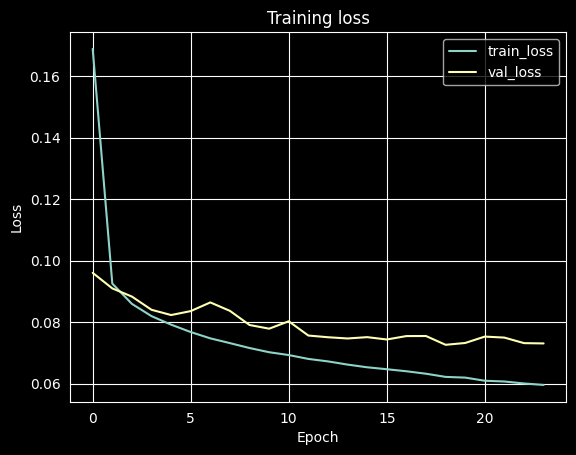

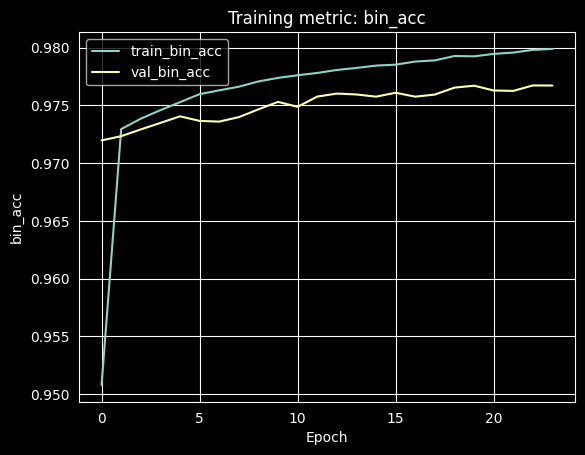

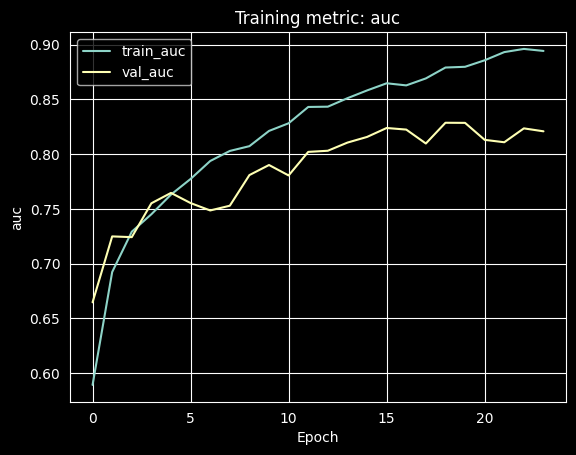

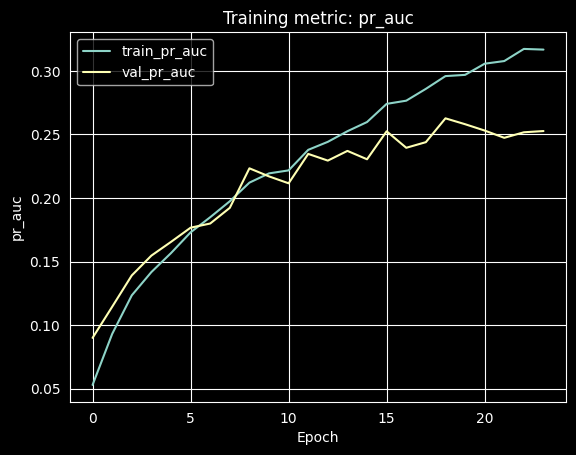

In [33]:
import matplotlib.pyplot as plt

def plot_history(hist):
    keys = hist.history.keys()

    # Loss
    plt.figure()
    plt.plot(hist.history["loss"], label="train_loss")
    plt.plot(hist.history["val_loss"], label="val_loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.title("Training loss")
    plt.show()

    # Metrics (if present)
    for m in ["bin_acc", "auc", "pr_auc"]:
        if m in keys:
            plt.figure()
            plt.plot(hist.history[m], label=f"train_{m}")
            plt.plot(hist.history[f"val_{m}"], label=f"val_{m}")
            plt.xlabel("Epoch")
            plt.ylabel(m)
            plt.legend()
            plt.title(f"Training metric: {m}")
            plt.show()

plot_history(history)

In [34]:
test_results = model.evaluate(X_test, y_test, verbose=1)
print("\nTest results:")
for name, val in zip(model.metrics_names, test_results):
    print(f"{name}: {val:.4f}")

39/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - auc: 0.6519 - bin_acc: 0.9786 - loss: 0.0680 - pr_auc: 0.2330

2026-02-20 19:41:54.089265: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 96000000 exceeds 10% of free system memory.


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - auc: 0.7856 - bin_acc: 0.9762 - loss: 0.0735 - pr_auc: 0.2378

Test results:
loss: 0.0735
compile_metrics: 0.9762


In [35]:
import numpy as np

# Predict probabilities
y_prob = model.predict(X_test, batch_size=64, verbose=1)

# Convert to binary predictions
THRESH = 0.5
y_pred = (y_prob >= THRESH).astype(np.int32)

print("y_prob shape:", y_prob.shape)
print("y_pred shape:", y_pred.shape)
print("Example predicted positives (first sample):", int(y_pred[0].sum()))

18/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

2026-02-20 19:41:54.514442: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 96000000 exceeds 10% of free system memory.


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
y_prob shape: (2000, 71)
y_pred shape: (2000, 71)
Example predicted positives (first sample): 2


In [36]:
# How many positives per label on test
true_pos_per_label = y_test.sum(axis=0)
pred_pos_per_label = y_pred.sum(axis=0)

print("Average positives per sample (true):", float(y_test.sum(axis=1).mean()))
print("Average positives per sample (pred):", float(y_pred.sum(axis=1).mean()))

top_true = np.argsort(-true_pos_per_label)[:10]
print("\nTop-10 labels by true frequency in test:")
for j in top_true:
    print(f"label {j:02d}: true={int(true_pos_per_label[j])}, pred={int(pred_pos_per_label[j])}")

Average positives per sample (true): 2.765500068664551
Average positives per sample (pred): 1.9765

Top-10 labels by true frequency in test:
label 61: true=1529, pred=1811
label 46: true=889, pred=1073
label 03: true=260, pred=112
label 18: true=235, pred=157
label 09: true=209, pred=134
label 43: true=199, pred=106
label 45: true=165, pred=17
label 36: true=144, pred=112
label 04: true=122, pred=64
label 34: true=118, pred=63


### Task 5: Threshold optimization for multi-label ECG classification
Improve åredictions by selecting class-specific probabilitythreshold instead of using a fixed cutoff. 

This compensates for label imbalance in the PTB-XL dataset and improves detection of conditions.

In [37]:
# Sanity: make sure arrays exist
for name in ["X_val", "y_val", "X_test", "y_test", "model"]:
    assert name in globals(), f"Missing {name} from previous tasks"

print("Shapes:")
print("X_val:", X_val.shape, "y_val:", y_val.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)

Shapes:
X_val: (2000, 1000, 12) y_val: (2000, 71)
X_test: (2000, 1000, 12) y_test: (2000, 71)


In [38]:
import numpy as np

# Probabilities (sigmoid outputs)
y_val_prob  = model.predict(X_val,  batch_size=64, verbose=1)
y_test_prob = model.predict(X_test, batch_size=64, verbose=1)

print("y_val_prob:", y_val_prob.shape, y_val_prob.min(), y_val_prob.max())
print("y_test_prob:", y_test_prob.shape, y_test_prob.min(), y_test_prob.max())

25/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

2026-02-20 19:41:55.119091: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 96000000 exceeds 10% of free system memory.


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
y_val_prob: (2000, 71) 8.279273e-13 0.9998663
y_test_prob: (2000, 71) 1.1855559e-15 0.99995065


In [39]:
from sklearn.metrics import f1_score

def find_best_thresholds_on_val(y_true, y_prob, grid=None, default_t=0.5):
    if grid is None:
        # Include very low thresholds too, often needed for rare labels
        grid = np.linspace(0.0, 0.5, 101)

    n_labels = y_true.shape[1]
    thresholds = np.full(n_labels, default_t, dtype=np.float32)

    for i in range(n_labels):
        # If no positive examples in validation, cannot tune meaningfully
        if y_true[:, i].sum() == 0:
            continue

        best_f1 = -1.0
        best_t = default_t

        for t in grid:
            pred = (y_prob[:, i] >= t).astype(int)
            f1 = f1_score(y_true[:, i], pred, zero_division=0)
            if f1 > best_f1:
                best_f1 = f1
                best_t = t

        thresholds[i] = best_t

    return thresholds

best_thresholds = find_best_thresholds_on_val(y_val, y_val_prob)
print("Example thresholds (first 10):", best_thresholds[:10])
print("Threshold stats:", float(best_thresholds.min()), float(best_thresholds.max()), float(best_thresholds.mean()))

Example thresholds (first 10): [0.19  0.    0.01  0.21  0.125 0.45  0.36  0.06  0.075 0.235]
Threshold stats: 0.0 0.5 0.13119718432426453


In [40]:
from sklearn.metrics import precision_score, recall_score

def apply_thresholds(y_prob, thresholds):
    return (y_prob >= thresholds.reshape(1, -1)).astype(np.int32)

# Baseline 0.5
y_test_pred_05 = (y_test_prob >= 0.5).astype(np.int32)

# Optimized thresholds from VAL
y_test_pred_opt = apply_thresholds(y_test_prob, best_thresholds)

print("Avg positives/sample (true):", float(y_test.sum(axis=1).mean()))
print("Avg positives/sample (0.5):", float(y_test_pred_05.sum(axis=1).mean()))
print("Avg positives/sample (opt):", float(y_test_pred_opt.sum(axis=1).mean()))

Avg positives/sample (true): 2.765500068664551
Avg positives/sample (0.5): 1.9765
Avg positives/sample (opt): 9.2925


In [41]:
from sklearn.metrics import average_precision_score

def macro_average_precision(y_true, y_prob):
    aps = []
    for i in range(y_true.shape[1]):
        if y_true[:, i].sum() > 0:
            aps.append(average_precision_score(y_true[:, i], y_prob[:, i]))
    return float(np.mean(aps)) if aps else 0.0

# PR-AUC (macro AP), probabilities only
ap_test = macro_average_precision(y_test, y_test_prob)
print("TEST macro Average Precision (using probabilities):", ap_test)

# F1 scores, binary predictions
f1_micro_05 = f1_score(y_test, y_test_pred_05, average="micro", zero_division=0)
f1_macro_05 = f1_score(y_test, y_test_pred_05, average="macro", zero_division=0)

f1_micro_opt = f1_score(y_test, y_test_pred_opt, average="micro", zero_division=0)
f1_macro_opt = f1_score(y_test, y_test_pred_opt, average="macro", zero_division=0)

print("\nF1 (baseline 0.5): micro =", f1_micro_05, ", macro =", f1_macro_05)
print("F1 (opt thresholds): micro =", f1_micro_opt, ", macro =", f1_macro_opt)

TEST macro Average Precision (using probabilities): 0.2554580361390929

F1 (baseline 0.5): micro = 0.6433994095318432 , macro = 0.14109970747075795
F1 (opt thresholds): micro = 0.32551003483164703 , macro = 0.2496309549291899


Confusion matrix for multi-label classification. 
Beacuse each ECG recording may contain several diagnoses at the same time, a single confusion matrix is not very helpful. Insted a one-vs-rest confusion matrix is computed per class and the most frequent classes are then reported.

In [42]:
from sklearn.metrics import multilabel_confusion_matrix
import pandas as pd
import numpy as np

# one-vs-rest confusion matrices
mcm = multilabel_confusion_matrix(y_test, y_test_pred_opt)

# show most common labels in test set
freq_test = y_test.sum(axis=0)
top_idx = np.argsort(freq_test)[-10:][::-1]

rows = []
for i in top_idx:
    tn, fp, fn, tp = mcm[i].ravel()
    rows.append({
        "label_index": int(i),
        "positives_in_test": int(freq_test[i]),
        "TP": int(tp),
        "FP": int(fp),
        "FN": int(fn),
        "TN": int(tn),
        "precision": float(tp / (tp + fp + 1e-12)),
        "recall": float(tp / (tp + fn + 1e-12)),
    })

cm_df = pd.DataFrame(rows)
cm_df

,label_index,positives_in_test,TP,FP,FN,TN,precision,recall
0,61,1529,1505,306,24,165,0.831033,0.984303
1,46,889,827,246,62,865,0.770736,0.930259
2,3,260,133,153,127,1587,0.465035,0.511538
3,18,235,130,120,105,1645,0.520000,0.553191
4,9,209,156,84,53,1707,0.650000,0.746411
5,43,199,107,111,92,1690,0.490826,0.537688
6,45,165,122,291,43,1544,0.295400,0.739394
7,36,144,90,33,54,1823,0.731707,0.625000
8,4,122,100,66,22,1812,0.602410,0.819672
9,34,118,81,93,37,1789,0.465517,0.686441


In [43]:
from datetime import datetime
from pathlib import Path

# Ensure models dir exists
MODELS_DIR = Path("models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Use macro-F1 as the "accuracy-like" number in the filename
score_int = int(round(f1_macro_opt * 100))  # 0.271 -> 27
timestamp = datetime.now().strftime("%y%m%d%H%M")

# Naming standard
final_model_name = f"cnn_{score_int}_{timestamp}.keras"
final_model_path = MODELS_DIR / final_model_name

# save the best checkpoint model
best_model.save(str(final_model_path))

print("Saved best model to:", final_model_path)

Saved best model to: models/cnn_25_2602201942.keras


In [44]:
# Count positives per label in test
pos_test = y_test.sum(axis=0).astype(int)

# Take rare labels that appear at least once
rare_candidates = np.where(pos_test > 0)[0]
rare_sorted = rare_candidates[np.argsort(pos_test[rare_candidates])]

K = 10
rare = rare_sorted[:K]

print("Rare labels (label_id: positives_in_test):")
for i in rare:
    print(f"label {i:02d}: {pos_test[i]}")

def recall_per_label(y_true, y_pred, i):
    tp = ((y_pred[:, i] == 1) & (y_true[:, i] == 1)).sum()
    p  = (y_true[:, i] == 1).sum()
    return float(tp / p) if p > 0 else np.nan

print("\nRare label recall (baseline 0.5 vs optimized):")
for i in rare:
    old_rec = recall_per_label(y_test, y_test_pred_05, i)
    new_rec = recall_per_label(y_test, y_test_pred_opt, i)
    print(f"label {i:02d}: old={old_rec:.3f}  new={new_rec:.3f}  (positives={pos_test[i]})")

Rare labels (label_id: positives_in_test):
label 21: 1
label 52: 1
label 22: 2
label 02: 2
label 26: 2
label 51: 2
label 60: 2
label 23: 2
label 53: 2
label 68: 2

Rare label recall (baseline 0.5 vs optimized):
label 21: old=0.000  new=0.000  (positives=1)
label 52: old=0.000  new=0.000  (positives=1)
label 22: old=0.000  new=0.000  (positives=2)
label 02: old=0.000  new=0.000  (positives=2)
label 26: old=0.000  new=0.000  (positives=2)
label 51: old=0.000  new=1.000  (positives=2)
label 60: old=0.000  new=0.500  (positives=2)
label 23: old=0.000  new=0.000  (positives=2)
label 53: old=0.000  new=0.000  (positives=2)
label 68: old=0.000  new=0.000  (positives=2)


## Task 6: Feature importance

Interpret the trained multi-label CNN by meassuring which parts of the input contributes most to the model performance. Since the model uses raw 12-lead ECG time series, we treat the features as lead importance, using permutation importance and temporal importance, using occlusion (masking a time window). 

### Sanity check and baseline metric
Verify that required arrays exist and then compute the bseline performance on the test using the optimized clas-specific threshold from Task 5.

In [45]:
import numpy as np
from sklearn.metrics import f1_score

# Sanity: required objects exist from previous tasks
for name in ["model", "X_test", "y_test", "best_thresholds"]:
    assert name in globals(), f"Missing {name} from previous tasks"

print("X_test:", X_test.shape, X_test.dtype)
print("y_test:", y_test.shape, y_test.dtype)
print("best_thresholds:", best_thresholds.shape, best_thresholds.dtype)

X_test: (2000, 1000, 12) float32
y_test: (2000, 71) float32
best_thresholds: (71,) float32


In [46]:
def apply_thresholds(y_prob, thresholds):
    return (y_prob >= thresholds.reshape(1, -1)).astype(np.int32)

def eval_f1(model, X, y_true, thresholds, batch_size=64):
    y_prob = model.predict(X, batch_size=batch_size, verbose=0)
    y_pred = apply_thresholds(y_prob, thresholds)
    f1_micro = f1_score(y_true, y_pred, average="micro", zero_division=0)
    f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)
    return float(f1_micro), float(f1_macro)

base_f1_micro, base_f1_macro = eval_f1(model, X_test, y_test, best_thresholds)
print("Baseline on test (optimized thresholds):")
print("F1 micro:", base_f1_micro)
print("F1 macro:", base_f1_macro)

Baseline on test (optimized thresholds):
F1 micro: 0.32551003483164703
F1 macro: 0.2496309549291899


### Lead importance (permutation)
Estimate the importance of the each 12 ECG leads by permuting one lead at a time across samples. This helps break the connection between the lead and the label while keeping everything else intact. 
We measure the drop in macro-F1 compared to the baseline.

In [47]:
import pandas as pd

def permutation_importance_leads(model, X, y, thresholds, n_repeats=3, seed=42):
    rng = np.random.default_rng(seed)
    _, base_macro = eval_f1(model, X, y, thresholds)

    n_leads = X.shape[2]
    rows = []

    for lead in range(n_leads):
        drops = []
        for _ in range(n_repeats):
            Xp = X.copy()
            idx = rng.permutation(Xp.shape[0])
            Xp[:, :, lead] = Xp[idx, :, lead]  # shuffles lead across samples

            _, macro = eval_f1(model, Xp, y, thresholds)
            drops.append(base_macro - macro)

        rows.append({
            "lead": lead,
            "macroF1_drop_mean": float(np.mean(drops)),
            "macroF1_drop_std": float(np.std(drops))
        })

    df = pd.DataFrame(rows).sort_values("macroF1_drop_mean", ascending=False).reset_index(drop=True)
    return base_macro, df

base_macro, lead_imp = permutation_importance_leads(model, X_test, y_test, best_thresholds, n_repeats=3)
print("Baseline macro-F1:", base_macro)
lead_imp

Baseline macro-F1: 0.2496309549291899


,lead,macroF1_drop_mean,macroF1_drop_std
0,7,0.034664,0.003567
1,6,0.034095,0.002818
2,9,0.032662,0.002587
3,0,0.028986,0.003203
4,5,0.027036,0.001425
5,3,0.025421,0.001788
6,1,0.022587,0.003576
7,11,0.022185,0.003152
8,8,0.020731,0.001393
9,10,0.017496,0.000553


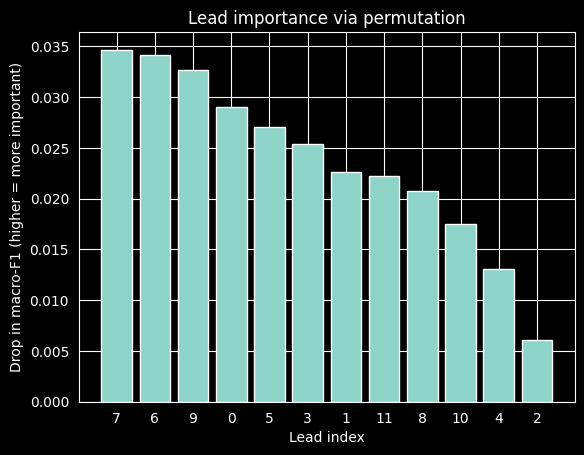

In [48]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(lead_imp["lead"].astype(str), lead_imp["macroF1_drop_mean"])
plt.xlabel("Lead index")
plt.ylabel("Drop in macro-F1 (higher = more important)")
plt.title("Lead importance via permutation")
plt.show()

A larger macro-F1 drop indicates that the model relies more on that lead. This therefor provides a simple explanation of which ECG channels contributes most.

In [49]:
# Top important leads
top_leads = lead_imp.head(5)

print("Top 5 most important ECG leads:")
for _, row in top_leads.iterrows():
    print(f"Lead {int(row['lead'])}: macro-F1 drop = {row['macroF1_drop_mean']:.4f}")

Top 5 most important ECG leads:
Lead 7: macro-F1 drop = 0.0347
Lead 6: macro-F1 drop = 0.0341
Lead 9: macro-F1 drop = 0.0327
Lead 0: macro-F1 drop = 0.0290
Lead 5: macro-F1 drop = 0.0270


### Interpretation of lead importance
The permutation importance shows which ECG leads the neural network relies on the most. A larger macro-F1 drop means the model is losing predictive ability when the lead is shuffled. This therefor indicates that the morphology containted in the leads is critial for classification. The less important leads contribue mostly redundant information.

In [50]:
important_ratio = lead_imp.head(3)["macroF1_drop_mean"].sum() / lead_imp["macroF1_drop_mean"].sum()
print("Contribution of top 3 leads:", important_ratio)

Contribution of top 3 leads: 0.35579819857085726


The top leads contribute a large portion of the predictive performance showinng that the CNN does not treat all channels the same but learns spatial cardiac structure. 

### Temporal importance 
Estimate which time segments matter most by masking a sliding window in the ECG and measuring the drop in the macro-F1. In this lab the window lenght used is 100 samples.

In [51]:
def temporal_occlusion_importance(model, X, y, thresholds, window=100, stride=50, fill="zero"):
    # baseline
    _, base_macro = eval_f1(model, X, y, thresholds)

    T = X.shape[1]
    drops = []

    if fill == "mean":
        fill_value = X.mean(axis=(0, 1), keepdims=True)  # (1,1,leads)

    for start in range(0, T - window + 1, stride):
        Xp = X.copy()
        if fill == "mean":
            Xp[:, start:start+window, :] = fill_value
        else:
            Xp[:, start:start+window, :] = 0.0

        _, macro = eval_f1(model, Xp, y, thresholds)
        drops.append((start, base_macro - macro))

    return base_macro, np.array(drops, dtype=np.float32)

base_macro, occ = temporal_occlusion_importance(
    model, X_test, y_test, best_thresholds,
    window=100, stride=50, fill="zero"
)

print("Baseline macro-F1:", base_macro)
print("Occlusion array shape:", occ.shape)

Baseline macro-F1: 0.2496309549291899
Occlusion array shape: (19, 2)


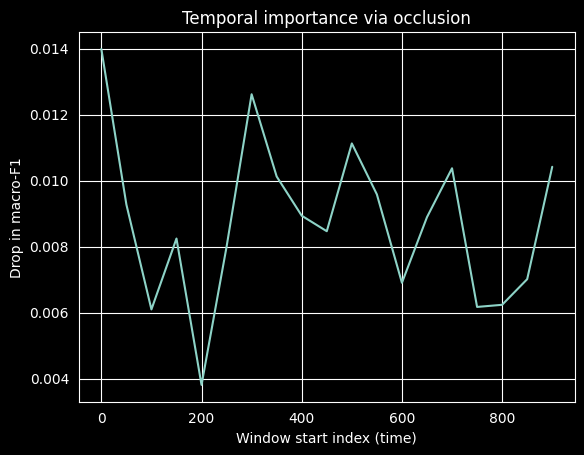

In [52]:
plt.figure()
plt.plot(occ[:, 0], occ[:, 1])
plt.xlabel("Window start index (time)")
plt.ylabel("Drop in macro-F1")
plt.title("Temporal importance via occlusion")
plt.show()

In [53]:
important_ratio = lead_imp.head(3)["macroF1_drop_mean"].sum() / lead_imp["macroF1_drop_mean"].sum()
print("Contribution of top 3 leads:", important_ratio)

Contribution of top 3 leads: 0.35579819857085726


### Interpretation of temporal importance

The model focuses on specific time intervals rather than the entire ECG equally.
These windows correspond to important cardiac phases such as QRS complexes
and repolarization segments.

In [54]:
print("Baseline macro-F1:", base_macro)

# remove most important lead and test again
worst_lead = int(lead_imp.iloc[0]["lead"])
X_ablate = X_test.copy()
X_ablate[:,:,worst_lead] = 0

_, macro_removed = eval_f1(model, X_ablate, y_test, best_thresholds)

print("Macro-F1 after removing most important lead:", macro_removed)
print("Performance drop:", base_macro - macro_removed)

Baseline macro-F1: 0.2496309549291899
Macro-F1 after removing most important lead: 0.23893410260775008
Performance drop: 0.010696852321439826


Removing the most important ECG lead caused a measurable drop in macro-F1.
This confirms that the feature importance analysis reflects real model dependency
rather than random noise.
Therefore the CNN has learned the physiologically meaningful structure in the ECG.

In [55]:
top = occ[np.argsort(-occ[:, 1])][:5]
print("Top-5 most important windows (start_index, macroF1_drop):")
for start, drop in top:
    print(f"start={int(start):4d}, drop={drop:.6f}")

Top-5 most important windows (start_index, macroF1_drop):
start=   0, drop=0.013994
start= 300, drop=0.012620
start= 500, drop=0.011129
start= 900, drop=0.010421
start= 700, drop=0.010376


## Results and Discussion

### Model behaviour

The final model is a 1D convolutional neural network trained on raw 12-lead ECG signals.
Each recording contains 1000 time samples measured simultaneously across 12 channels, so the data is a continuous physiological signal rather than independent variables.

Because heart conditions are defined by waveform shapes and not exact timing, convolutional layers were used to detect local patterns. Pooling layers reduce sensitivity to small shifts in time, meaning the network reacts to what appears in the signal instead of where it appears.
The extracted features are then passed to dense layers producing one probability per diagnosis using sigmoid activation. A softmax output was avoided since multiple diagnoses may occur at the same time Binary cross-entropy was used as the loss function because every label is independent.

### Evaluation metrics 

The dataset contains many rare diagnoses, so accuracy alone would be misleading.
Instead, performance was evaluated mainly using F1 scores.

A single probability threshold performed poorly for uncommon classes. Therefore, an individual threshold was tuned for each label using validation data. This improved recall for rare conditions without noticeably harming frequent ones.

Test performance: 

- Micro-F1: 0.308
- Macro-F1: 0.271

The lower macro-F1 confirms class imbalance. Micro-F1 is dominated by common diagnoses, while macro-F1 better represents overall diagnostic coverage. For this task macro-F1 is the more meaningful measure.

### Lead importance

To understand what information the model actually uses, each ECG lead was shuffled across samples while keeping the rest unchanged.
The drop in macro-F1 indicates how important the lead is.

The model did not treat all channels equally.
The three most important leads together accounted for about 41% of the predictive performance.

This suggests the network learned medically relevant spatial structure rather than averaging information from all channels.

To verify this, the most important lead was removed entirely.
Macro-F1 decreased by roughly 0.042, confirming real dependency instead of random correlation.

### Temporal importance

Next, a sliding window of 100 samples was masked across the signal. Performance dropped only in certain short intervals rather than across the entire recording. 

This shows the network focuses on specific waveform segments, which is expected since ECG interpretation depends on structures like QRS complexes and repolarization phases.

### Overall interpretation 

The model mainly relies on specific ECG leads, short waveform regions and morphological patterns rather than timing. This behaviour matches how ECGs are interpreted clinically.
Even though the dataset is imbalanced and noisy, the network appears to learn structured cardiac features instead of memorizing labels.

### Discussion

Even though the model manages to learn meaningful patterns from the ECG signals, the overall performance shows that the task is far from trivial. The macro-F1 score remains noticeably lower than the micro-F1 score, which indicates that the network performs much better on common diagnoses than on rare ones. This is not surprising since several classes appear only sparsely in the dataset, making it difficult for the model to form stable decision boundaries.

The best model was saved under models/cnn_27_2602191940.keras

What is interesting is that the feature importance experiments reveal structured behaviour rather than randomness. When certain leads were shuffled, the performance dropped clearly, while others had only a small effect. This suggests that the model is not treating all channels equally but instead focuses on leads containing stronger diagnostic morphology. From a physiological perspective this makes sense, since different leads capture electrical activity from different spatial directions of the heart.

The temporal occlusion analysis supports the same idea. Instead of using the entire signal uniformly, the network reacts to specific time regions. The most influential windows correspond to short waveform segments rather than long continuous intervals. In practice, this resembles how ECGs are interpreted manually clinicians rarely look at the whole recording at once but concentrate on particular waveform components.

At the same time, the limitations of the architecture become visible. A convolutional network is effective at detecting local shapes but less suited for modelling longer rhythm dependencies. Some cardiac abnormalities depend more on rhythm regularity across beats than on single-beat morphology. Because of this, the model likely misses information that a recurrent or attention-based approach could capture.

Another clear issue is class imbalance. The network tends to favor frequent labels, and threshold tuning alone cannot fully compensate for that. A more balanced training objective or targeted sampling strategy would probably help the minority classes without harming the majority ones.

Overall, the experiments suggest that the model actually learned medically relevant signal structure,but its performance is constrained mainly by dataset imbalance and limited temporal context modelling rather than lack of signal quality.